# *Setup*

In [1]:
import sys
import os
sys.path.append(os.path.abspath(".."))

import numpy as np
from numpy import format_float_positional as ffp
from scipy import stats
import pandas as pd

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

from src.preprocessing import clean_data, get_transformers
from src.modeling import random_search_with_kfoldcv, parallelized_random_search_with_kfoldcv
from src.evaluation import evaluate, display_best_hyperparam_combinations
from src.utils import save_models, load_models

In [2]:
df = pd.read_csv('../data/raw/WA_Fn-UseC_-Telco-Customer-Churn.csv')
df = clean_data(df)

df_X = df.drop(columns='Churn')
df_y = df.loc[:, ['Churn']].copy()

df_X_train, df_X_test, df_y_train, df_y_test = train_test_split(df_X, df_y, test_size=0.25, shuffle=True, stratify=df_y, random_state=7)
print('Dataset de Treinamento:', df_X_train.shape, df_y_train.shape)
print('Dataset de Testes:', df_X_test.shape, df_y_test.shape)

transformers_X, transformer_y = get_transformers(df_X=df_X, df_y=df_y)

models = {}

Dataset de Treinamento: (5282, 19) (5282, 1)
Dataset de Testes: (1761, 19) (1761, 1)


# Treinamento e Avaliação Individual dos Modelos

## ***Baseline***: Regressão Logística (**LR**)

In [5]:
X_train_transformed = transformers_X['LR'].fit_transform(df_X_train)
X_test_transformed = transformers_X['LR'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [6]:
models['LR'] = LogisticRegression(C=np.inf,
                                  tol=1e-4,
                                  fit_intercept=True,
                                  solver='lbfgs',
                                  max_iter=1000,
                                  n_jobs=1,
                                  random_state=7)

models['LR'].fit(X=X_train_transformed,
                 y=y_train.reshape(-1))

LogisticRegression(C=inf, max_iter=1000, n_jobs=1, random_state=7)

,Treinamento,Teste
Acurácia,0.808,0.810
Precisão,0.667,0.672
Recall,0.553,0.552
F1-Score,0.605,0.606
F2.-Score,0.572,0.573
AUROC,-----,0.858
AUPR,-----,0.679


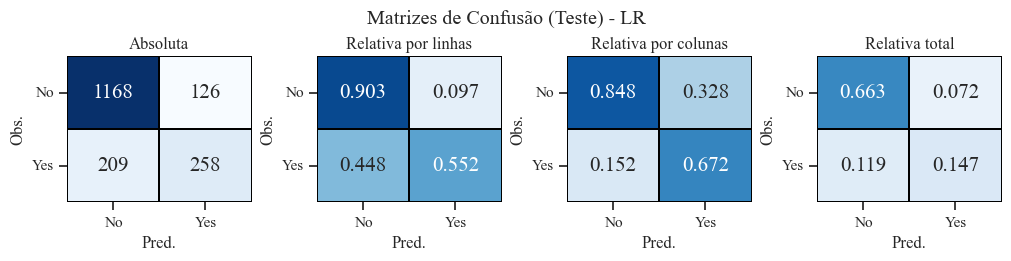

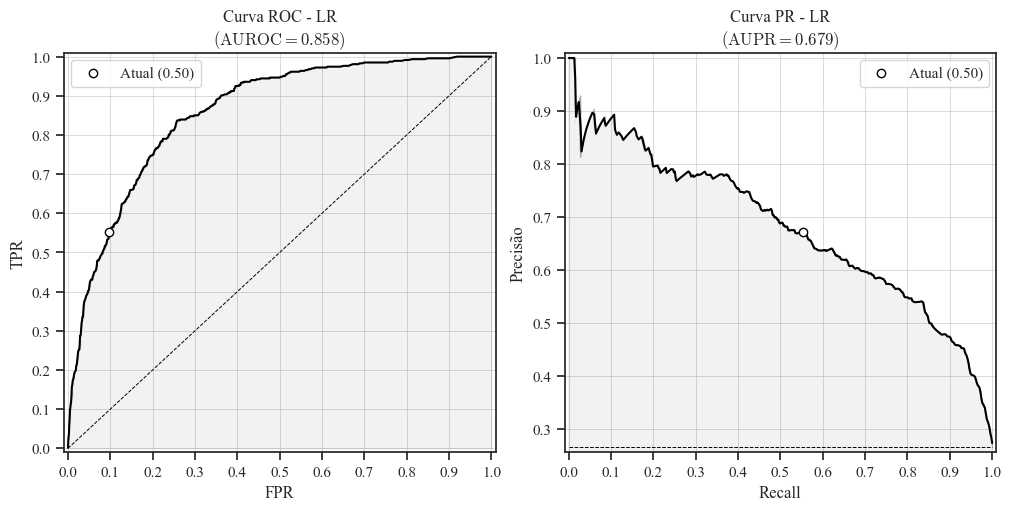

In [7]:
_ = evaluate(
    model=models['LR'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_LR.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_LR.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_LR.png',
    model_title=' - LR')

## Árvore de Decisão (**DT**)

### Otimização de Hiperparâmetros

In [53]:
hyperparam_dist = {'ccp_alpha':stats.loguniform(a=1e-4, b=1e3),
                   'criterion':['gini', 'entropy'],
                   'min_samples_split':stats.randint(2, 40+1)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=DecisionTreeClassifier(random_state=7),
                                                                     n_comb=1000, k=5,
                                                                     transformer_X=transformers_X['DT'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)

#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_DT.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=None, sort_by='min_samples_split', ascending=False,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'ccp_alpha':lambda x: ffp(x)})

,ccp_alpha,criterion,min_samples_split,auc (mean),auc (std),auc (se)
447,0.0028075893645747,entropy,38,0.824055,0.008793,0.003932
415,0.0022209819057637,entropy,36,0.824147,0.010528,0.004708
184,0.0022261659343238,entropy,36,0.824147,0.010528,0.004708
219,0.0020711402088147,entropy,32,0.824378,0.008559,0.003828
778,0.0020716321265925,entropy,31,0.824378,0.008559,0.003828
908,0.002028035819188,entropy,31,0.823948,0.007217,0.003227
453,0.0026797550974218,entropy,29,0.825207,0.009578,0.004283
378,0.0017907619083377,entropy,24,0.822683,0.007146,0.003196
858,0.0018400565213841,entropy,22,0.822622,0.007976,0.003567
187,0.0027797196395198,entropy,18,0.824240,0.008740,0.003908


### Treinamento final e Avaliação

In [8]:
X_train_transformed = transformers_X['DT'].fit_transform(df_X_train)
X_test_transformed = transformers_X['DT'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [9]:
# Combinação de hiperparâmetros nº 447
models['DT'] = DecisionTreeClassifier(ccp_alpha=0.0028075893645747984,
                                      min_samples_split=38,
                                      criterion='entropy',
                                      random_state=7)
models['DT'].fit(X=X_train_transformed,
                 y=y_train.reshape(-1))

DecisionTreeClassifier(ccp_alpha=0.0028075893645747984, criterion='entropy',
                       min_samples_split=38, random_state=7)

,Treinamento,Teste
Acurácia,0.791,0.793
Precisão,0.684,0.677
Recall,0.392,0.418
F1-Score,0.499,0.517
F2.-Score,0.429,0.452
AUROC,-----,0.837
AUPR,-----,0.665


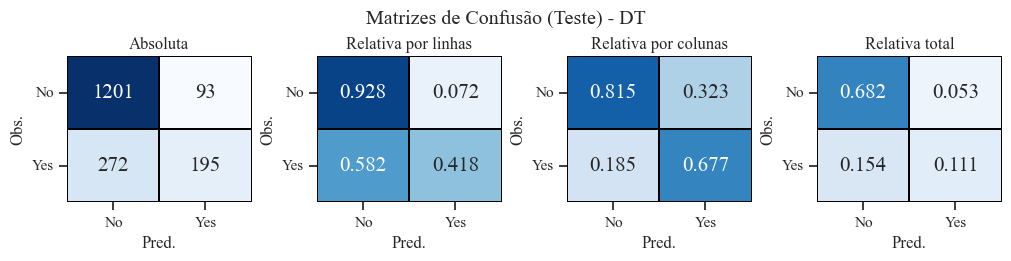

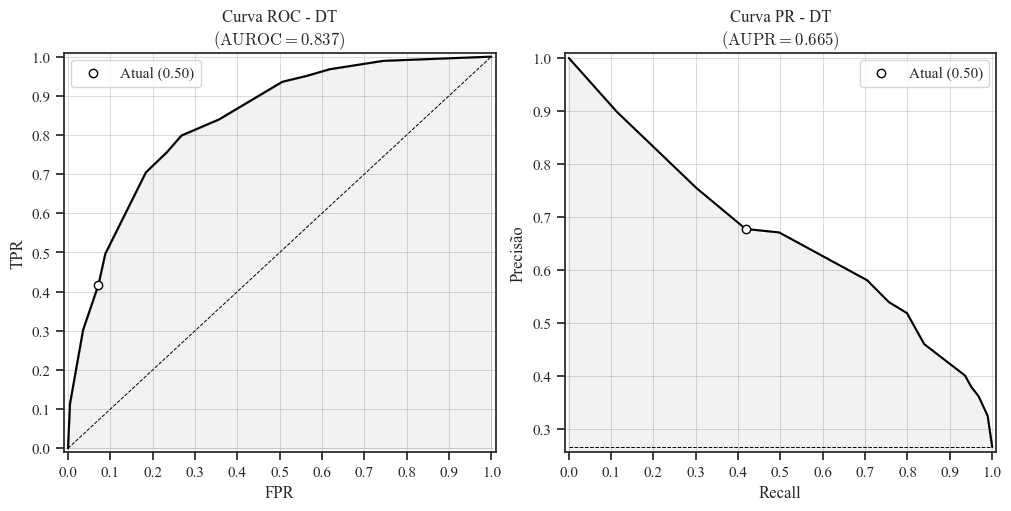

In [10]:
_ = evaluate(
    model=models['DT'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_DT.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_DT.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_DT.png',
    model_title=' - DT')

## Floresta Aleatória (**RF**)

### Otimização de Hiperparâmetros

In [56]:
hyperparam_dist = {'n_estimators':stats.randint(10, 500+1),
                   'criterion':['gini', 'entropy'],
                   'max_features':stats.uniform(0, 1),
                   'max_depth':list(range(2, 20+1, 2)) + [None]}

df_hyperparam_optimization = random_search_with_kfoldcv(model=RandomForestClassifier(random_state=7, n_jobs=-1),
                                                        n_comb=100, k=5,
                                                        transformer_X=transformers_X['RF'], transformer_y=transformer_y,
                                                        df_X_train=df_X_train, df_y_train=df_y_train,
                                                        hyperparam_distributions=hyperparam_dist,
                                                        verbose_tqdm=True,
                                                        global_seed=7)
                                                        
#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_RF.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=None, sort_by='n_estimators', ascending=True,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'max_features':lambda x: ffp(x)})

,n_estimators,criterion,max_features,max_depth,auc (mean),auc (std),auc (se)
84,29,gini,0.7963907007825485,6,0.838109,0.012203,0.005457
46,48,gini,0.4129918291138346,4,0.838407,0.013529,0.006050
25,85,gini,0.1331694457592501,6,0.839800,0.015130,0.006766
67,243,gini,0.945048223792794,6,0.839627,0.011862,0.005305
63,262,gini,0.3088526848637971,6,0.841652,0.012437,0.005562
43,322,gini,0.3703510829880352,4,0.838682,0.013343,0.005967
93,339,gini,0.8756717248700833,4,0.837840,0.013059,0.005840
7,358,gini,0.0720511333597615,6,0.837002,0.015713,0.007027
60,359,gini,0.955468323002926,6,0.839985,0.012002,0.005367
81,389,gini,0.414901772573252,6,0.841928,0.012438,0.005562


### Treinamento final e Avaliação

In [11]:
X_train_transformed = transformers_X['RF'].fit_transform(df_X_train)
X_test_transformed = transformers_X['RF'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [12]:
# Combinação de hiperparâmetros nº 84
models['RF'] = RandomForestClassifier(n_estimators=29,
                                      max_features=0.7963907007825485,
                                      criterion='gini',
                                      max_depth=6,
                                      n_jobs=-1,
                                      random_state=7)
models['RF'].fit(X=X_train_transformed,
                 y=y_train.reshape(-1))

RandomForestClassifier(max_depth=6, max_features=0.7963907007825485,
                       n_estimators=29, n_jobs=-1, random_state=7)

,Treinamento,Teste
Acurácia,0.819,0.809
Precisão,0.711,0.686
Recall,0.536,0.518
F1-Score,0.611,0.590
F2.-Score,0.563,0.545
AUROC,-----,0.854
AUPR,-----,0.683


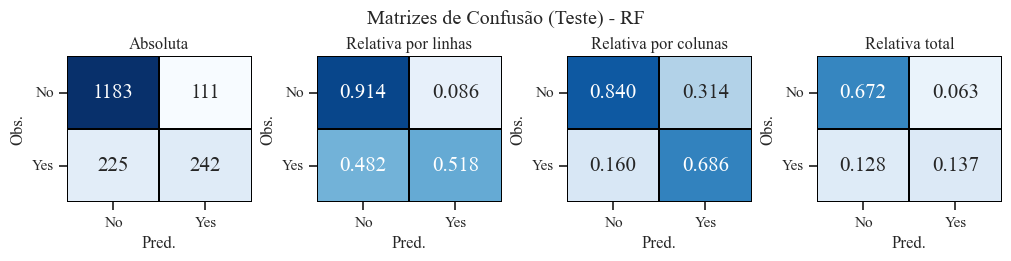

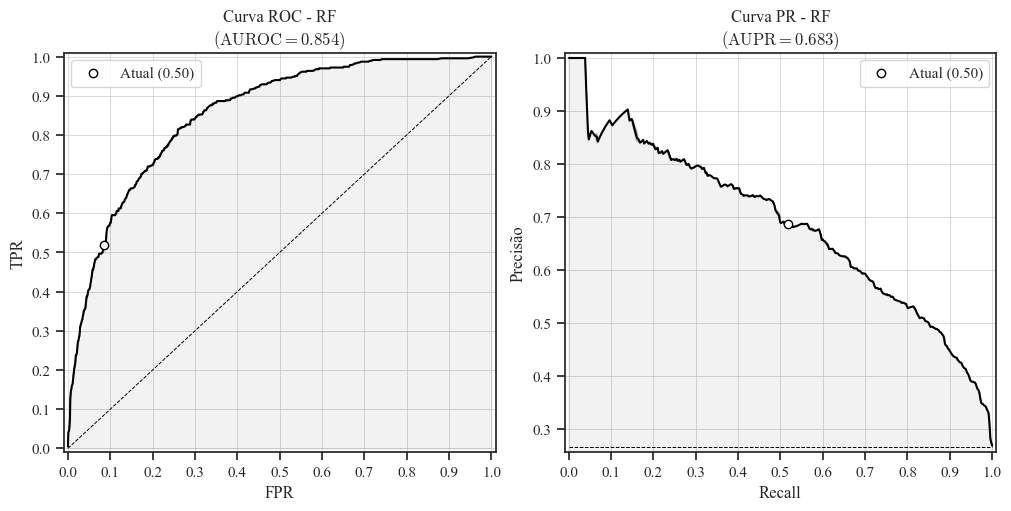

In [13]:
_ = evaluate(
    model=models['RF'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_RF.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_RF.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_RF.png',
    model_title=' - RF')

## K-Vizinhos mais Próximos (**KNN**)

### Otimização de Hiperparâmetros

In [58]:
hyperparam_dist = {'n_neighbors':stats.randint(1, 200+1),
                   'weights':['uniform', 'distance'],
                   'p':stats.randint(1, 5+1)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=KNeighborsClassifier(metric='minkowski'),
                                                                     n_comb=1000, k=5,
                                                                     transformer_X=transformers_X['KNN'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)
                                                                     
#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_KNN.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=10, sort_by='n_neighbors', ascending=True,
                                     with_one_standard_error_rule=True,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={})

,n_neighbors,weights,p,auc (mean),auc (std),auc (se)
84,22,uniform,4,0.824173,0.015339,0.006860
840,22,uniform,2,0.824332,0.016440,0.007352
983,22,uniform,2,0.824332,0.016440,0.007352
697,23,uniform,1,0.824607,0.015949,0.007133
9,24,uniform,3,0.826397,0.015728,0.007034
922,24,uniform,3,0.826397,0.015728,0.007034
584,25,uniform,3,0.826300,0.015991,0.007151
739,26,uniform,1,0.825300,0.015988,0.007150
543,26,uniform,5,0.826966,0.014758,0.006600
656,27,uniform,3,0.826338,0.016484,0.007372


### Treinamento final e Avaliação

In [14]:
X_train_transformed = transformers_X['KNN'].fit_transform(df_X_train)
X_test_transformed = transformers_X['KNN'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [15]:
models['KNN'] = KNeighborsClassifier(n_neighbors=22,
                                     weights='uniform',
                                     p=2,
                                     metric='minkowski',
                                     n_jobs=-1)
models['KNN'].fit(X=X_train_transformed,
                  y=y_train.reshape(-1))

KNeighborsClassifier(n_jobs=-1, n_neighbors=22)

,Treinamento,Teste
Acurácia,0.808,0.794
Precisão,0.639,0.612
Recall,0.631,0.612
F1-Score,0.635,0.612
F2.-Score,0.633,0.612
AUROC,-----,0.847
AUPR,-----,0.658


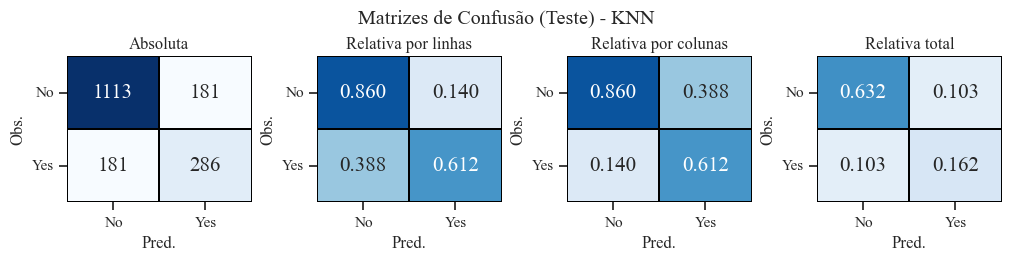

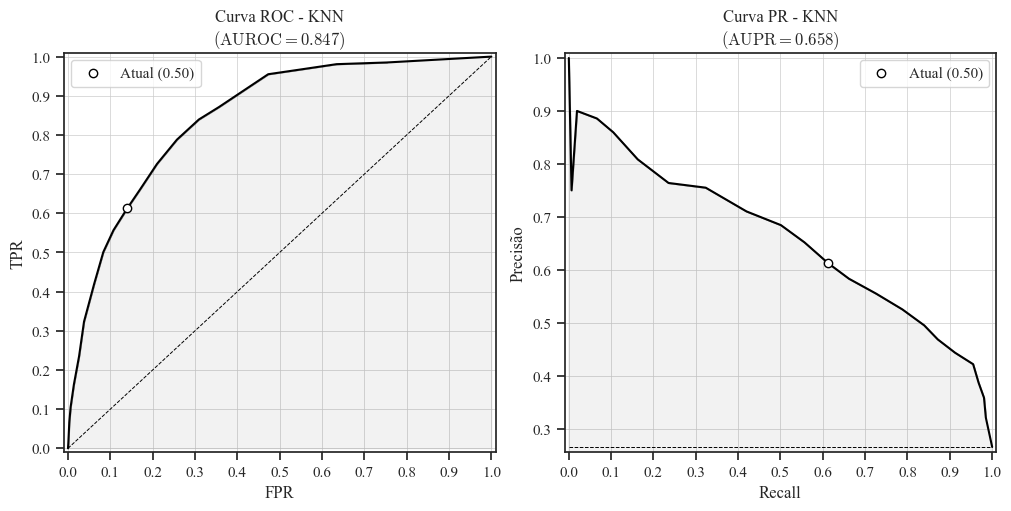

In [16]:
_ = evaluate(
    model=models['KNN'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_KNN.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_KNN.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_KNN.png',
    model_title=' - KNN')

## Máquinas de Vetores de Suporte (**SVM**)

### Otimização de Hiperparâmetros

In [61]:
hyperparam_dist = {'C':stats.loguniform(2**-10, 2**10),
                   'gamma':stats.loguniform(2**-20, 2**5)}

df_hyperparam_optimization = parallelized_random_search_with_kfoldcv(model=SVC(random_state=7, kernel='rbf', probability=True),
                                                                     n_comb=100, k=5,
                                                                     transformer_X=transformers_X['SVM'], transformer_y=transformer_y,
                                                                     df_X_train=df_X_train, df_y_train=df_y_train,
                                                                     hyperparam_distributions=hyperparam_dist,
                                                                     n_jobs=5,
                                                                     global_seed=7)
                                                                     
#df_hyperparam_optimization.to_csv('../reports/tables/hyperparam-optimization_SVM.csv')

display_best_hyperparam_combinations(df=df_hyperparam_optimization,
                                     n_best=10, sort_by=None, ascending=False,
                                     with_one_standard_error_rule=False,
                                     metric_mean_column='auc (mean)',
                                     metric_se_column='auc (se)',
                                     style_format={'C':lambda x:ffp(x), 'gamma':lambda x:ffp(x)})

,C,gamma,auc (mean),auc (std),auc (se)
92,0.0017158226880264,0.00000192914796952792,0.831361,0.019382,0.008668
56,0.003508930082791,0.000004717842365609852,0.831327,0.019397,0.008674
19,0.0013791399232851,0.0000014682007641057004,0.831320,0.019505,0.008723
16,0.0188108267967449,0.00003848441491494224,0.831281,0.019720,0.008819
55,0.0009960719731237,0.000000977548768559336,0.831235,0.019476,0.008710
76,0.0065129297278917,0.000010221050238172716,0.831194,0.019525,0.008732
71,0.0060126339578758,0.000009249238731931034,0.831172,0.019846,0.008875
80,0.0096854044419903,0.00001678503431063868,0.831164,0.019428,0.008689
7,0.002651496698028,0.0000033238307076191213,0.831129,0.019564,0.008749
98,0.0075095982254409,0.000012212256300004909,0.831084,0.019487,0.008715


### Treinamento final e Avaliação

In [17]:
X_train_transformed = transformers_X['SVM'].fit_transform(df_X_train)
X_test_transformed = transformers_X['SVM'].transform(df_X_test)
y_train = transformer_y.fit_transform(df_y_train)
y_test  = transformer_y.transform(df_y_test)

In [18]:
models['SVM'] = SVC(C=0.0017158226880264926,
                    gamma=0.00000192914796952792,
                    kernel='rbf',
                    probability=True,
                    random_state=7)
models['SVM'].fit(X=X_train_transformed,
                  y=y_train.reshape(-1))

SVC(C=0.0017158226880264926, gamma=1.92914796952792e-06, probability=True,
    random_state=7)

,Treinamento,Teste
Acurácia,0.795,0.800
Precisão,0.626,0.637
Recall,0.561,0.567
F1-Score,0.592,0.600
F2.-Score,0.573,0.580
AUROC,-----,0.847
AUPR,-----,0.665


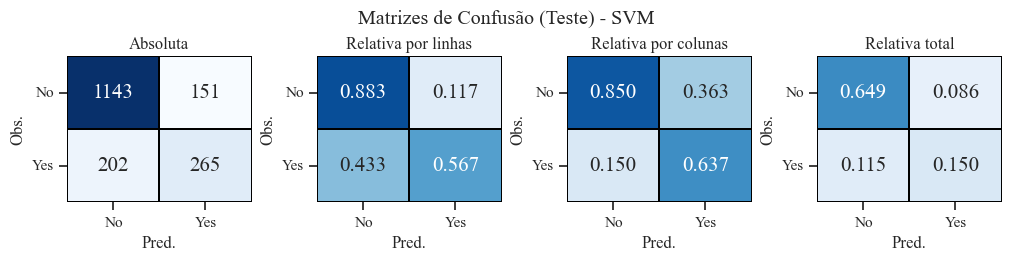

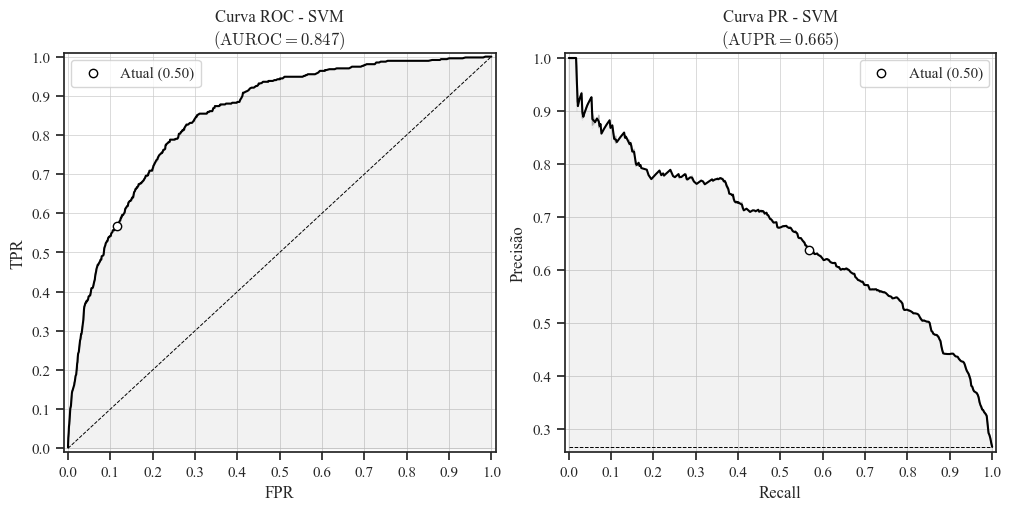

In [19]:
_ = evaluate(
    model=models['SVM'],
    X_train=X_train_transformed, X_test=X_test_transformed, y_train=y_train, y_test=y_test,
    beta_fscore=2, threshold=0.5, threshold_step=0.001,
    display_metrics_table=True, plot_confusion_matrix=True, plot_roc_pr_curve=True,
    save_metrics_table=True, save_confusion_matrix=True, save_roc_pr_curve=True,
    path_metrics_table='../reports/tables/model-evaluation_SVM.csv',
    path_confusion_matrix='../reports/figures/confusion-matrix_SVM.png',
    path_roc_pr_curve='../reports/figures/roc-pr-curves_SVM.png',
    model_title=' - SVM')

# Salvando e Carregando os Modelos Treinados

In [44]:
save_models(models_dict=models, path='../models/', format='.pkl')

In [3]:
models = load_models(models_names=['LR', 'DT', 'KNN', 'RF', 'SVM'], path='../models/', format='.pkl')